# Model router batch

Model router for Microsoft Foundry is a deployable AI chat model that is trained to select the best large language model (LLM) to respond to a given prompt in real time. By evaluating factors like query complexity, cost, and performance, it intelligently routes requests to the most suitable model. Thus, it delivers high performance while saving on compute costs where possible, all packaged as a single model deployment.

## Anthropic models added
Version 2025-11-18 of model router adds support for three Anthropic models: claude-haiku-4-5, claude-opus-4-1, and claude-sonnet-4-5. To include these in your model router deployment, you need to first deploy them yourself to your Foundry resource (see Deploy and use Claude models). Then enable them with model subset configuration in your model router deployment.

## Model router GA version
A new model router model is now available. Version 2025-11-18 includes support for all underlying models in previous versions, as well as 10 new language models.

It also includes new features that make it more versatile and effective.

Routing profiles let you skew model router's choices to optimize for quality or cost while maintaining a baseline level of performance.
Model router supports custom subsets: you can specify which underlying models to include in routing decisions. This gives you more control over cost, compliance, and performance characteristics.

| Model router version | Underlying models | Underlying model version |
|---|---|---|
| 2025-11-18 | gpt-4.1 | 2025-04-14 |
| | gpt-4.1-mini | 2025-04-14 |
| | gpt-4.1-nano | 2025-04-14 |
| | o4-mini | 2025-04-16 |
| | gpt-5-nano | 2025-08-07 |
| | gpt-5-mini | 2025-08-07 |
| | gpt-5 | 2025-08-07 |
| | gpt-5-chat | 2025-08-07 |
| | Deepseek-v3.1 | N/A |
| | gpt-oss-120b | N/A |
| | llama4-maverick-instruct | N/A |
| | grok-4 | N/A |
| | grok-4-fast | N/A |
| | gpt-4o | 2024-11-20 |
| | gpt-4o-mini | 2024-07-18 |
| | claude-haiku-4-5 | 2025-10-01 |
| | claude-opus-4-1 | 2025-08-05 |
| | claude-sonnet-4-5 | 2025-09-29 |


> https://learn.microsoft.com/en-us/azure/ai-foundry/openai/concepts/model-router?view=foundry&preserve-view=true

In [1]:
#%pip install datasets

In [2]:
import datetime
import os
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
import time
import sys

from datasets import load_dataset
from dotenv import load_dotenv
from openai import OpenAI
from tqdm import tqdm

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

In [4]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 12-Dec-2025 09:04:03


## Settings

In [5]:
load_dotenv("azure.env")

True

In [6]:
deployment_name = "model-router"
api_version = "2025-11-18"

In [7]:
RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

## Quick test

In [8]:
client = OpenAI(
    base_url = os.getenv("endpoint"),
    api_key = os.getenv("key"),
)

In [9]:
def model_router(prompt):
    """ Model router """
    response = client.chat.completions.create(
        model=deployment_name,
        stream=False,
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant.",
            },
            {
                "role": "user",
                "content": prompt,
            }
        ],
        max_tokens=8192,
        temperature=0.7,
        top_p=0.95,
        frequency_penalty=0.0,
        presence_penalty=0.0,
    )

    return response

### Tests

In [10]:
start = time.time()

response = model_router("Hello")

print(f"Done in {(time.time() - start):.3f} seconds")

Done in 0.804 seconds


In [11]:
print("\033[1;31;34m")
print(json.dumps(response.model_dump(), indent=5))


{
     "id": "chatcmpl-CltMC54jTVsjPBWO21O90FGzuBUyl",
     "choices": [
          {
               "finish_reason": "stop",
               "index": 0,
               "logprobs": null,
               "message": {
                    "content": "Hello! How can I assist you today?",
                    "refusal": null,
                    "role": "assistant",
                    "annotations": [],
                    "audio": null,
                    "function_call": null,
                    "tool_calls": null
               },
               "content_filter_results": {
                    "hate": {
                         "filtered": false,
                         "severity": "safe"
                    },
                    "protected_material_code": {
                         "filtered": false,
                         "detected": false
                    },
                    "protected_material_text": {
                         "filtered": false,
                         "det

In [12]:
print(f"Answer: {response.choices[0].message.content}")

Answer: Hello! How can I assist you today?


In [13]:
print(f"Chosen model: {response.model}")

Chosen model: gpt-4.1-nano-2025-04-14


## Batch
https://huggingface.co/datasets/data-is-better-together/10k_prompts_ranked/blob/main/README.md

In [14]:
ds = load_dataset("data-is-better-together/10k_prompts_ranked")
ds

DatasetDict({
    train: Dataset({
        features: ['prompt', 'quality', 'metadata', 'avg_rating', 'num_responses', 'agreement_ratio', 'raw_responses', 'kind', 'cluster_description', 'topic'],
        num_rows: 10331
    })
})

In [15]:
df_prompts = ds['train'].to_pandas()['prompt']
df_prompts

0        Provide step-by-step instructions on how to ma...
1        Write a personal essay of at least 1000 words ...
2        In this research, we aim to investigate how te...
3        Did Karl Marx's theories on centralizing credi...
4        alter this api that gets a request like: {"0",...
                               ...                        
10326    show me how to set iam user, group and policie...
10327    Hi, is there any unified messaging service?\nA...
10328    Can you provide a comparison of the economies ...
10329                 forget about any prior conversations
10330    I want to create a multiple choice test of 10 ...
Name: prompt, Length: 10331, dtype: object

In [16]:
# Let's take a random sample
df_prompts_samples = df_prompts.sample(n=100, random_state=44)
len(df_prompts_samples)

100

In [17]:
df_prompts_samples

8666    Optimize the performance of the query below an...
5633    Can you solve and provide the value of 6461744...
23      Explain how the unique chemical composition of...
4267    What is the significance of the spiders in the...
4217    Elaborate on the physical and genetic disparit...
                              ...                        
5111                    pls tell me the size of the earth
2038    How can I configure i8N for reports developed ...
5694    Explain why the 9th Amendment to the US Consti...
9797    Help me draft a short letter asking my teacher...
5789    Question: Did Harry Houdini's wife make psychi...
Name: prompt, Length: 100, dtype: object

In [18]:
results_list = []

for prompt in tqdm(df_prompts_samples, desc="Processing prompts with Microsoft Foundry model router"):
    try:
        # Calling the model router
        start = time.time()
        results = model_router(prompt)
        elapsed = time.time() - start
        
        # Get results
        answer = results.choices[0].message.content
        model = results.model
        prompt_tokens = results.usage.prompt_tokens
        result_tokens = results.usage.completion_tokens
        total_tokens = results.usage.total_tokens
        reason_tokens = results.usage.completion_tokens_details.reasoning_tokens
        
        # Append to a list
        results_list.append({
            'prompt': prompt,
            'answer': answer,
            'model': model,
            'elapsed': elapsed,
            'prompt_tokens': prompt_tokens,
            'result_tokens': result_tokens,
            'total_tokens' : total_tokens,
            'reason_tokens' : reason_tokens,
            'success': True,
            'failed_reason': None,
        })

    except Exception as e:
        results_list.append({
            'prompt': prompt,
            'answer': None,
            'model': None,
            'elapsed': None,
            'prompt_tokens': None,
            'result_tokens': None,
            'total_tokens' : None,
            'reason_tokens' : None,
            'success': False,
            'failed_reason': str(e),
        })

    time.sleep(1)  # pause

Processing prompts with Microsoft Foundry model router: 100%|██████████| 100/100 [45:30<00:00, 27.30s/it]


In [31]:
df = pd.DataFrame(results_list)

In [32]:
csv_file = os.path.join(RESULTS_DIR, "results.csv")

df.to_csv(csv_file, sep=';')
!ls $csv_file -lh

-rwxrwxrwx 1 root root 417K Dec 12 09:50 results/results.csv


## Results

In [33]:
df

,prompt,answer,model,elapsed,prompt_tokens,result_tokens,total_tokens,reason_tokens,success,failed_reason
0,Optimize the performance of the query below an...,Here is an optimized and cleaned-up version of...,gpt-4.1-mini-2025-04-14,13.116086,654.0,1082.0,1736.0,0.0,True,None
1,Can you solve and provide the value of 6461744...,923106413526810,gpt-5-mini-2025-08-07,11.635908,42.0,847.0,889.0,832.0,True,None
2,Explain how the unique chemical composition of...,Deep-sea hydrothermal vents are chemical hot s...,gpt-5-mini-2025-08-07,30.770231,63.0,2275.0,2338.0,1152.0,True,None
3,What is the significance of the spiders in the...,Short version: the spiders aren’t literal; the...,gpt-5-2025-08-07,28.155320,37.0,2202.0,2239.0,1664.0,True,None
4,Elaborate on the physical and genetic disparit...,Below is an in-depth comparison of a taller (T...,gpt-5-nano-2025-08-07,73.774853,76.0,5281.0,5357.0,2752.0,True,None
...,...,...,...,...,...,...,...,...,...,...
95,pls tell me the size of the earth,Earth is an oblate spheroid. Key sizes and rel...,gpt-5-mini-2025-08-07,9.243102,24.0,679.0,703.0,448.0,True,None
96,How can I configure i8N for reports developed ...,"Here is a practical, end-to-end approach to in...",gpt-5-mini-2025-08-07,31.542459,34.0,2662.0,2696.0,1280.0,True,None
97,Explain why the 9th Amendment to the US Consti...,The 9th Amendment protects a fundamental idea ...,gpt-5-nano-2025-08-07,17.564834,30.0,2407.0,2437.0,2048.0,True,None
98,Help me draft a short letter asking my teacher...,"Dear [Teacher’s Name],\n\nI hope you’re well. ...",gpt-5-2025-08-07,16.513210,61.0,755.0,816.0,576.0,True,None


In [34]:
df.describe()

,elapsed,prompt_tokens,result_tokens,total_tokens,reason_tokens
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,26.389266,144.484848,2016.282828,2160.767677,1203.717172
std,23.523927,237.436667,1867.166384,1877.263123,1578.558087
min,0.970912,20.000000,71.000000,190.000000,0.000000
25%,10.021204,34.000000,762.500000,838.000000,256.000000
50%,19.332567,57.000000,1573.000000,1608.000000,768.000000
75%,32.897515,132.000000,2515.500000,2726.500000,1504.000000
max,115.366368,1492.000000,8192.000000,8430.000000,8192.000000


In [35]:
print(pd.concat([
    df['model'].value_counts(),
    df['model'].value_counts(normalize=True).mul(100).round(2)
], axis=1, keys=['count', '%']))

                         count      %
gpt-5-mini-2025-08-07       49  49.49
gpt-5-nano-2025-08-07       19  19.19
gpt-5-2025-08-07            14  14.14
gpt-4.1-mini-2025-04-14      9   9.09
o4-mini-2025-04-16           3   3.03
gpt-4.1-2025-04-14           3   3.03
gpt-4o-mini-2024-07-18       2   2.02


In [36]:
print(pd.concat([
    df['success'].value_counts(),
    df['success'].value_counts(normalize=True).mul(100).round(2)
], axis=1, keys=['count', '%']))

       count     %
True      99  99.0
False      1   1.0


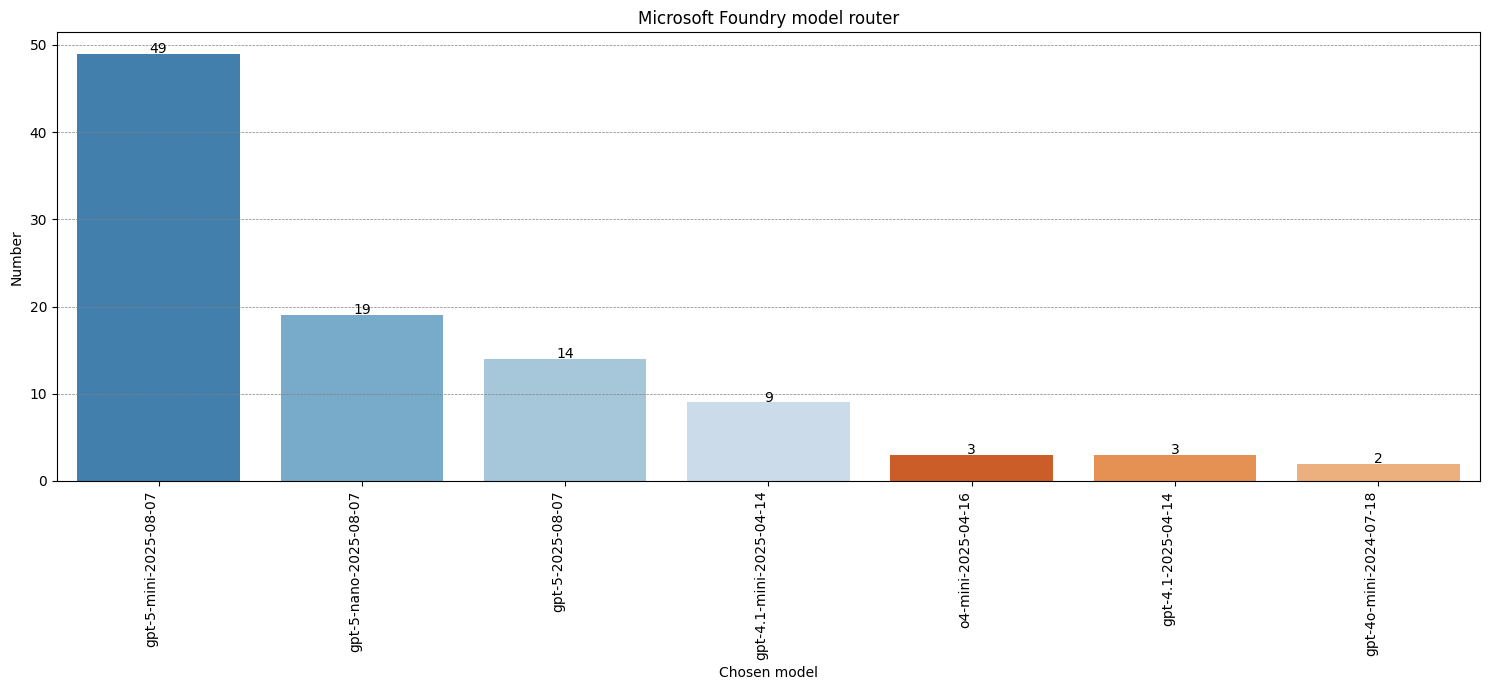

In [38]:
plt.figure(figsize=(15, 7))

model_counts = df['model'].value_counts(sort=True)
ax = sns.barplot(x=model_counts.index, y=model_counts.values, hue=model_counts.index, palette="tab20c", legend=False)
ax.set_title('Microsoft Foundry model router')
ax.set_xlabel('Chosen model')
ax.set_ylabel('Number')

for i, v in enumerate(model_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center')

plt.xticks(rotation=90, ha='right')
plt.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'number_per_model.png'), dpi=300, bbox_inches='tight')

plt.show()

In [39]:
df.pivot_table(values='elapsed', index='model', aggfunc='mean')
df.groupby('model')['elapsed'].describe()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gpt-4.1-2025-04-14,3.0,10.573421,10.830615,1.887031,4.505921,7.124812,14.916616,22.708419
gpt-4.1-mini-2025-04-14,9.0,11.547260,11.076344,1.894969,6.197922,7.378729,13.116086,38.615160
gpt-4o-mini-2024-07-18,2.0,6.680701,8.074861,0.970912,3.825806,6.680701,9.535595,12.390490
gpt-5-2025-08-07,14.0,31.305044,21.330688,1.477986,18.502169,27.785903,38.057650,90.838074
gpt-5-mini-2025-08-07,49.0,28.031053,24.286858,1.576572,12.342350,20.441540,31.542459,114.236852
gpt-5-nano-2025-08-07,19.0,32.917250,26.807622,3.832851,16.943039,26.696322,43.491573,115.366368
o4-mini-2025-04-16,3.0,8.770112,5.689345,3.108532,5.911756,8.714981,11.600901,14.486822


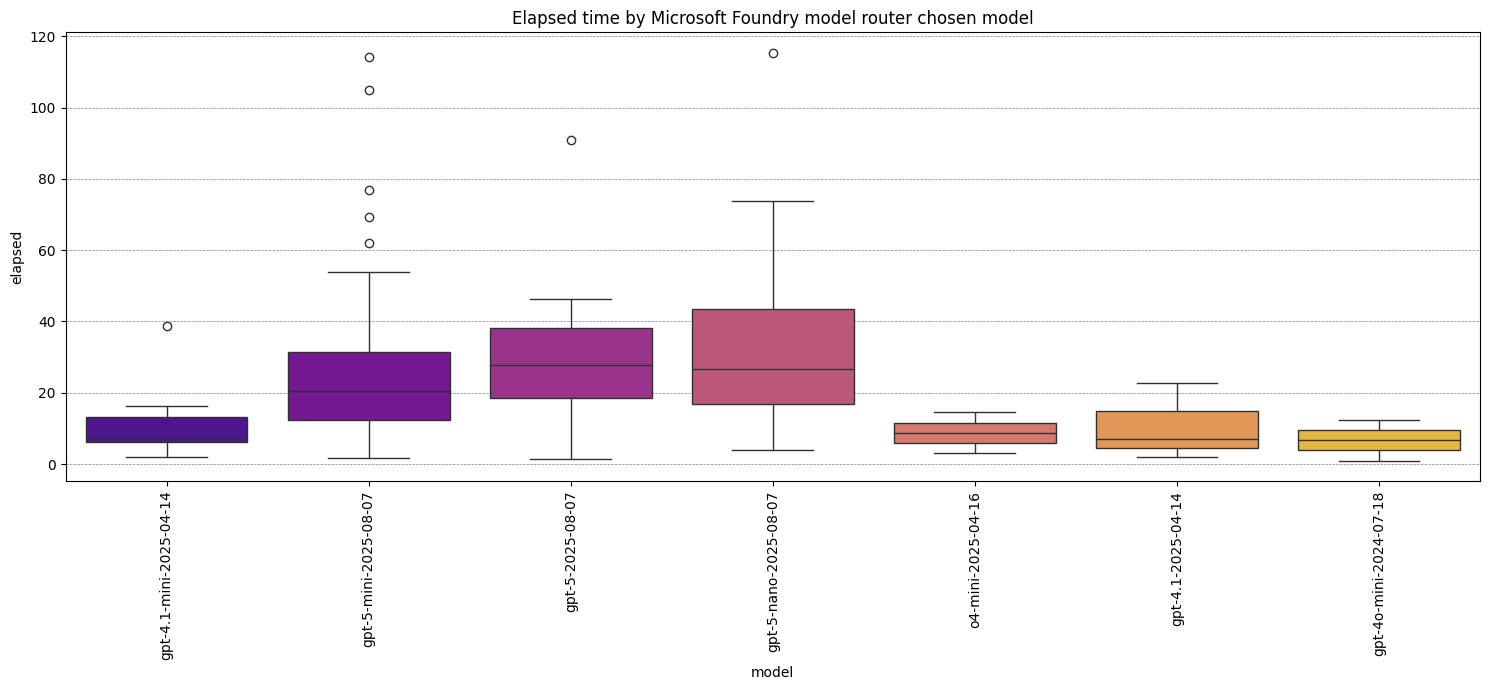

In [41]:
plt.figure(figsize=(15, 7))

sns.boxplot(data=df, x='model', y='elapsed', hue='model', palette="plasma", legend=False)
plt.title('Elapsed time by Microsoft Foundry model router chosen model')
plt.xticks(rotation=90)
plt.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'boxplot.png'), dpi=300, bbox_inches='tight')

plt.show()

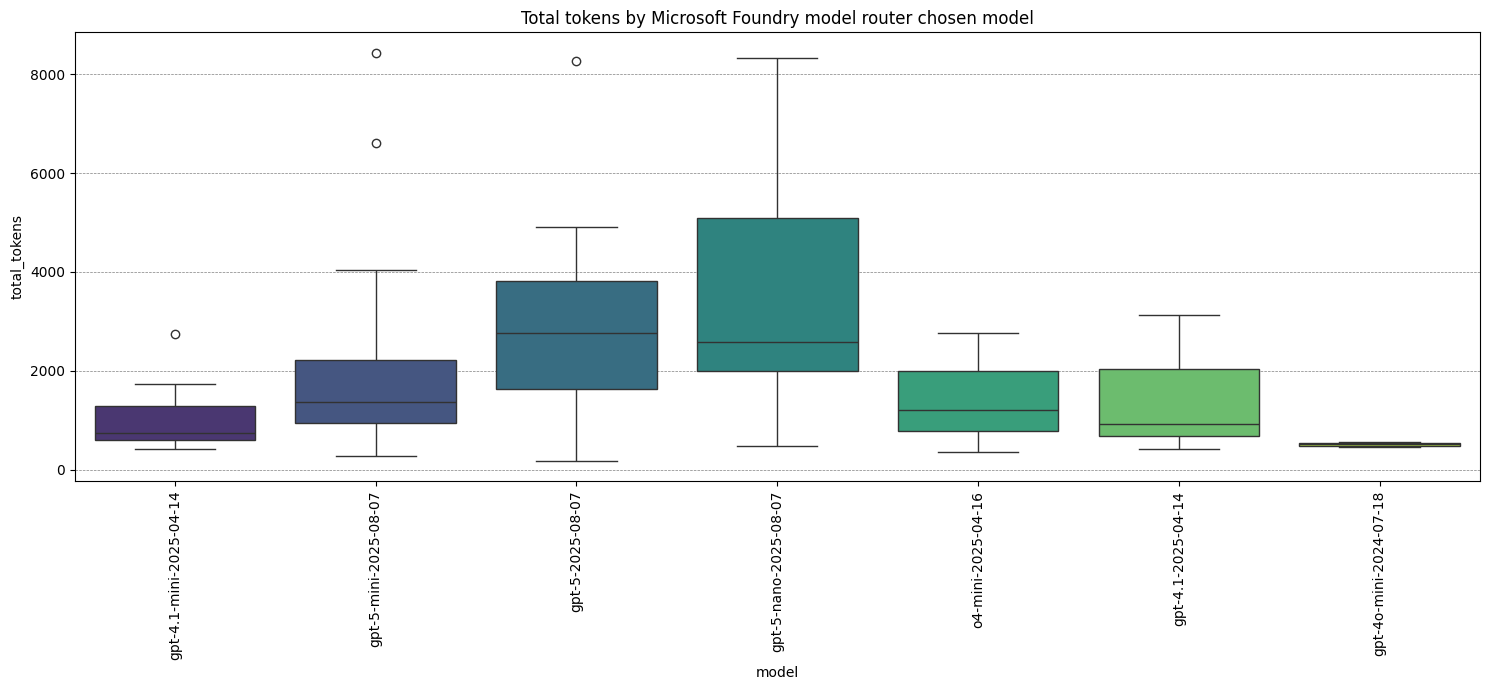

In [42]:
plt.figure(figsize=(15, 7))

sns.boxplot(data=df, x='model', y='total_tokens', hue='model', palette="viridis", legend=False)
plt.title('Total tokens by Microsoft Foundry model router chosen model')
plt.xticks(rotation=90)
plt.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'total_token_usage_per_model.png'), dpi=300, bbox_inches='tight')

plt.show()

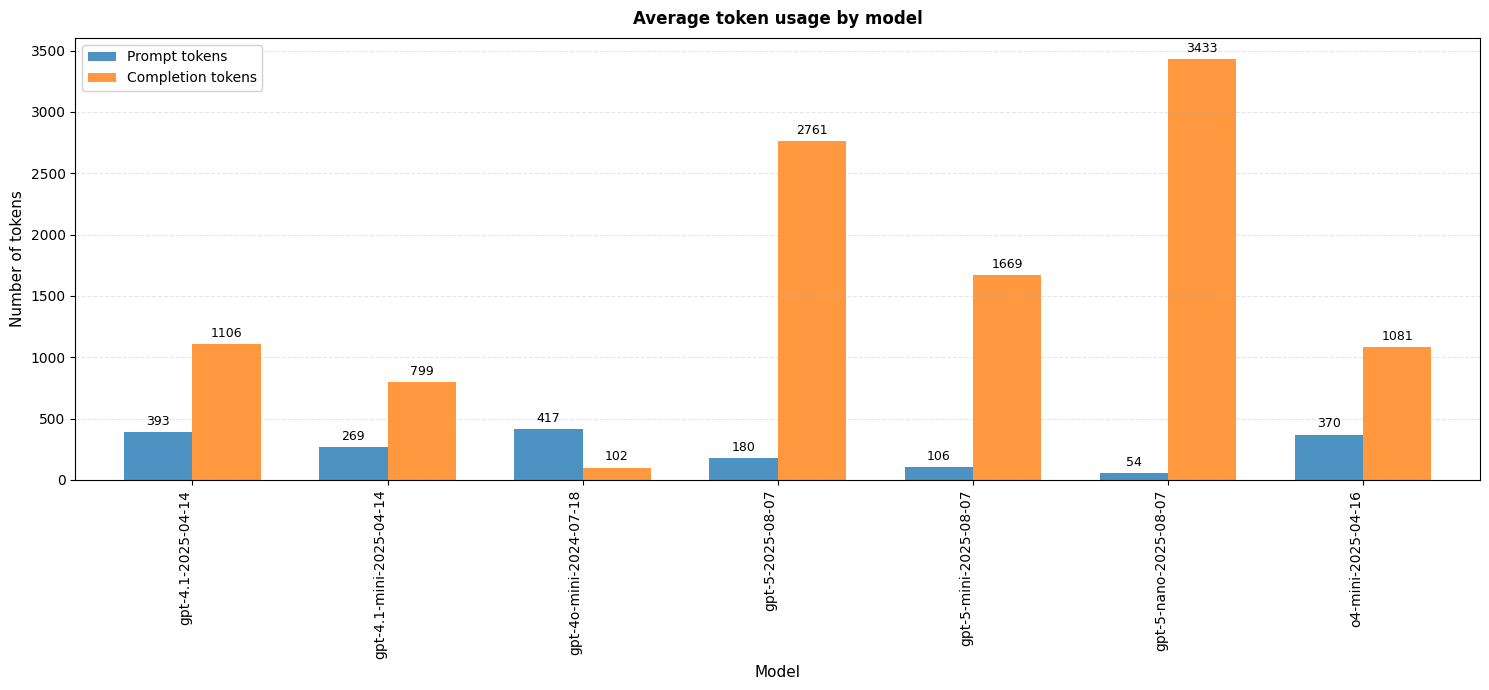

In [44]:
fig, ax = plt.subplots(figsize=(15, 7))

model_tokens = df.groupby('model')[['prompt_tokens', 'result_tokens']].mean()
model_tokens.plot(kind='bar', ax=ax, alpha=0.8, width=0.7, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Average token usage by model', fontweight='bold', fontsize=12, pad=10)
ax.set_ylabel('Number of tokens', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.legend(['Prompt tokens', 'Completion tokens'], framealpha=0.9, loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'average_token_usage_per_model.png'), dpi=300, bbox_inches='tight')

plt.show()

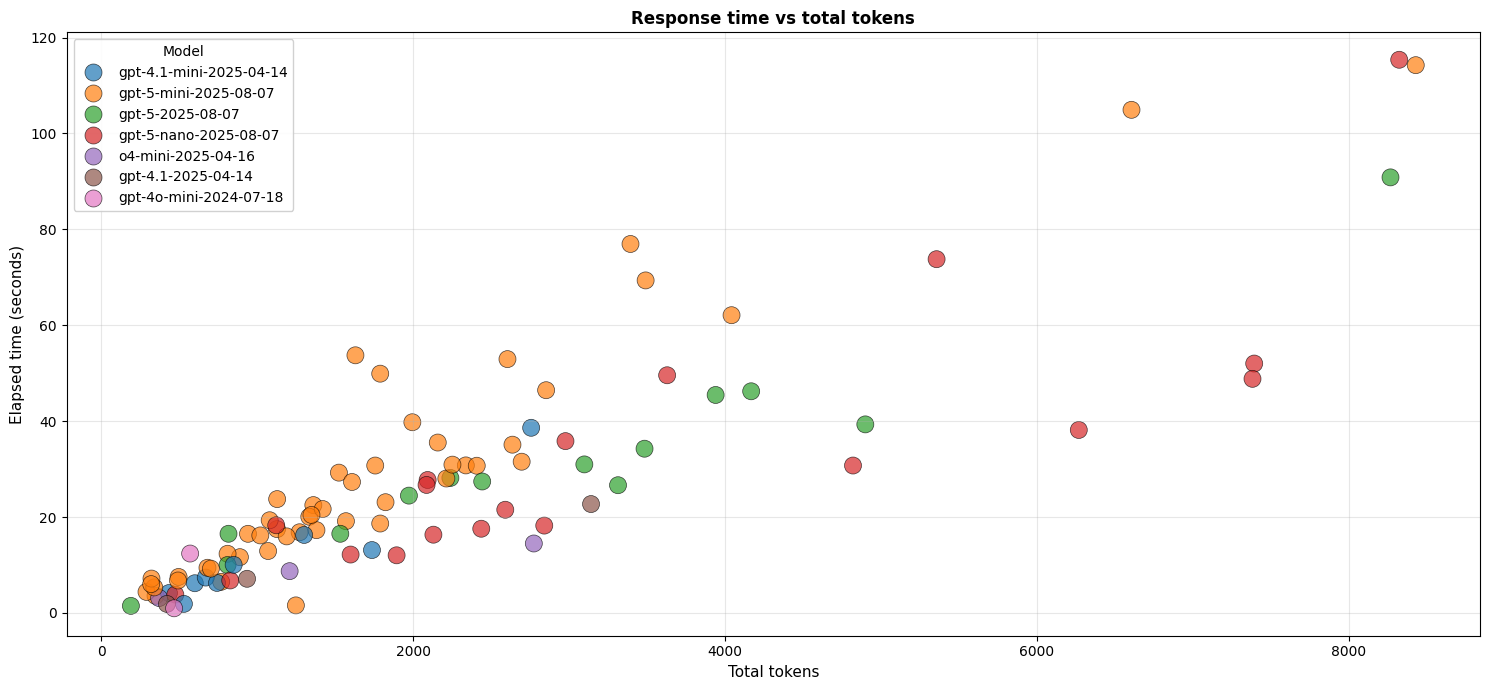

In [46]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=df, x='total_tokens', y='elapsed', hue='model', 
                s=150, alpha=0.7, edgecolor='black', linewidth=0.5, ax=ax)

ax.set_xlabel('Total tokens', fontsize=11)
ax.set_ylabel('Elapsed time (seconds)', fontsize=11)
ax.set_title('Response time vs total tokens', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(title='Model', loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'response_time_vs_total_tokens.png'), dpi=300, bbox_inches='tight')

plt.show()